In [908]:
import matplotlib.pyplot as plt
import mplcursors
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path
from utils import load_raw_results, standardize, load_results, proc_df, plots, plot_tests, symmetrical_colormap, param2modelstr
import utils
%matplotlib ipympl

# Debugging section

In [1020]:
p,df=utils.read_test_json(Path('results/AC.json'))
p

feedrate                         300
test_type                    careful
test_direction                  DOWN
test_loops                         0
test_num                           1
return_to_zero_after_test       True
n_samples                          1
careful_inc                      0.5
stop_after                        20
Name: AC, dtype: object

In [98]:
rparams, raw = load_raw_results()

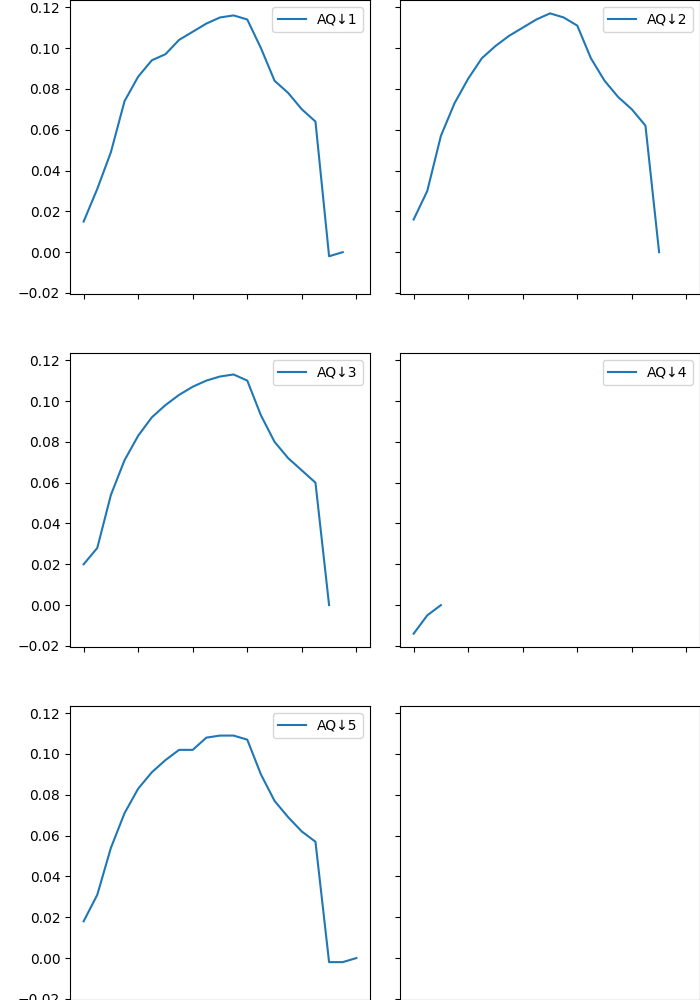

In [106]:
name = 'AQ'
plt.close('all')
fig, axs = plt.subplots(3,2, figsize=(7,10), sharex=True, sharey=True)
ddfs = [df for df in raw[name] if df.iloc[0].direction == "DOWN"]
udfs = [df for df in raw[name] if df.iloc[0].direction == "UP"]
for i,ax in enumerate(axs.flat[:5]):
    ddf = standardize(ddfs[i])
    testno = ddf.iloc[0].testno
    ddf.plot('displacement', 'force', ax=ax, label=f'{name}↓{testno}')
    #proc_df(ddf).plot('displacement', 'force', ax=ax, label=f'{name}↓{i}-new')
    #udf = standardize(udfs[i])
    #udf.plot('displacement', 'force', ax=ax, label=f'{name}↑{i}')
    #proc_df(udf).plot('displacement', 'force', ax=ax, label=f'{name}↑{i}-new')
plt.subplots_adjust(left=0.1,right=1,bottom=0,top=1,wspace=0.1)

Drop to first > 0


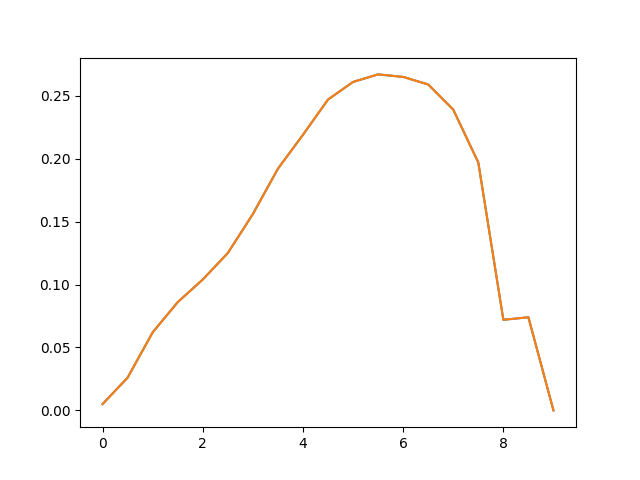

In [70]:
fig,ax = plt.subplots()
df = standardize(ddfs[0])
dfc = df.copy()
ax.plot(df.displacement, df.force)
df = proc_df(dfc)
#df.iloc[:10].force.eq(0)
ax.plot(df.displacement, df.force)

In [496]:
df.force.gt(0).argmax()

8

In [437]:
df.iloc[df.force[:len(df.force)//2].argmax()]

timestamp       1725277056.237996
direction                      UP
force                       0.093
test_type                 careful
z                            -6.6
displacement                  4.5
testno                          5
Name: 230, dtype: object

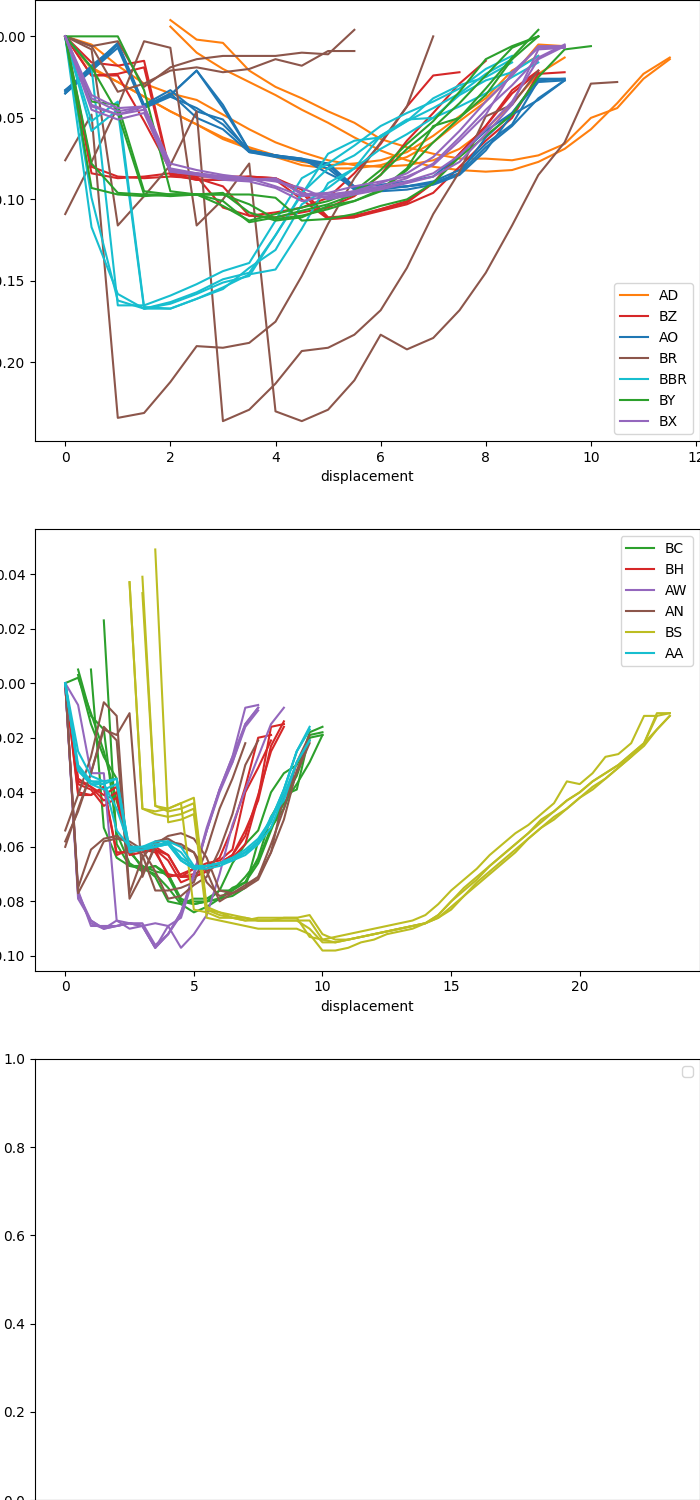

In [565]:
plt.close('all')
forces = np.array([.1, .05, 0])
fig, axs = plt.subplots(len(forces), 1, figsize=(7,15))
i = 0
for name, dfs in raw.items():
    maxforce = max(df.force.abs().max() for df in dfs) 
    maxthreshi = (maxforce > forces).argmax()
    ax = axs[maxthreshi]
    c = ax._get_lines.get_next_color()
    for df in dfs:
        if rparams.loc[name].model['Arm Type'] == 'Thread' and df.iloc[0].direction == 'UP':
            new_proc(standardize(df)).plot('displacement', 'force', color=c, ax=ax, label=name)
    remove_duplicate_legends(ax)
plt.subplots_adjust(left=0.05,right=1,bottom=0,top=1,wspace=0.1)

# Analysis section

In [1022]:
# Load the data!
params, data = load_results(modelinfo=models)

Missing model info for "BN", not loading
Missing model info for "AP", not loading
Missing model info for "BO", not loading
Missing model info for "BZ", not loading
Missing model info for "BBV", not loading
Missing model info for "BBT", not loading
Missing model info for "BBR", not loading
Missing model info for "AS", not loading
Missing model info for "BY", not loading
Missing model info for "BX", not loading
Models defined but without tests: AA_06mm, AA_08mm, AA_10mm, AA_15mm, AB_06mm, AB_08mm, AB_10mm, AB_15mm, AC_06mm, AC_08mm, AC_10mm, AC_15mm, AV, AX, AZ, BB, BI


In [1009]:
models = utils.modelinfo2df(utils.MODEL_INFO_PATH)

In [1010]:
for model in ('AA', 'AB', 'AC'):
    for mm in (6, 8, 10, 15):
        name = f'{model}_{mm:02}mm'
        models.loc[name] = models.loc[model].copy()
        models.loc[name,'Arm Eff Len'] = mm
models

,Symmetric,Arm Type,Angle,Arm Eff Len,In-Plane Th,Out-P Th,Base Width,w_b_ratio,displacement_calc
Names,,,,,,,,,
AA,True,Thread,45,30,0.8/3,1.6/18,30,1.313333,23.617366
AB,True,Flexures,45,30,1.6,18,30,1.313333,23.617366
AC,True,Uniform,45,30,1.6,18,30,1.313333,23.617366
AD,False,Thread,45,30,0.8/3,1.6/18,30,1.313333,23.617366
AE,False,Flexures,45,30,1.6,18,30,1.313333,23.617366
AF,False,Uniform,45,30,1.6,18,30,1.313333,23.617366
AN,True,Thread,35,30,0.8/3,1.6/18,30,1.313333,19.157453
AO,True,Thread,40,30,0.8/3,1.6/18,30,1.313333,21.469106
AQ,True,Flexures,35,30,1.6,18,30,1.313333,19.157453


In [1011]:
tparams, tune_data = load_results(Path('tune_results').glob('*.json'), models)

Models defined but without tests: AD, AE, AF, AN, AO, AQ, AR, AT, AU, AV, AW, AX, AY, AZ, BA, BB, BC, BD, BE, BF, BG, BH, BI, BJ, BK, BL, BM, BP, BQ, BR, BS, BT, BU, BV, BW


In [1017]:
tparams

test                                               \
        feedrate test_type test_direction test_loops test_num   
AB_06mm      300   careful           DOWN          0        1   
AC_10mm      300   careful           DOWN          0        1   
AB_08mm      300   careful           DOWN          0        1   
AC_06mm      300   careful           DOWN          0        1   
AB           300   careful           DOWN          0        1   
AA_15mm      300   careful           DOWN          0        1   
AB_10mm      300   careful           DOWN          0        1   
AC_08mm      300   careful           DOWN          0        1   
AC           300   careful           DOWN          0        1   
AB_15mm      300   careful           DOWN          0        1   
AA_10mm      300   careful           DOWN          0        1   
AA           300   careful           DOWN          0        1   
AA_06mm      300   careful           DOWN          0        1   
AC_15mm      300   careful           DOWN          0        1   
AA_08mm      300   careful           DOWN          0        1   

                                                                       model  \
        return_to_zero_after_test n_samples careful_inc stop_after Symmetric   
AB_06mm                      True         1         0.5         20      True   
AC_10mm                      True         1         0.5         20      True   
AB_08mm                      True         1         0.5         20      True   
AC_06mm                      True         1         0.5         20      True   
AB                           True         1         0.5         20      True   
AA_15mm                      True         1         0.5         20      True   
AB_10mm                      True         1         0.5         20      True   
AC_08mm                      True         1         0.5         20      True   
AC                           True         1         0.5         20      True   
AB_15mm                      True         1         0.5         20      True   
AA_10mm                      True         1         0.5         20      True   
AA                           True         1         0.5         20      True   
AA_06mm                      True         1         0.5         20      True   
AC_15mm                      True         1         0.5         20      True   
AA_08mm                      True         1         0.5         20      True   

                                                                               \
         Arm Type Angle Arm Eff Len In-Plane Th Out-P Th Base Width w_b_ratio   
AB_06mm  Flexures    45           6         1.6       18         30  1.313333   
AC_10mm   Uniform    45          10         1.6       18         30  1.313333   
AB_08mm  Flexures    45           8         1.6       18         30  1.313333   
AC_06mm   Uniform    45           6         1.6       18         30  1.313333   
AB       Flexures    45          30         1.6       18         30  1.313333   
AA_15mm    Thread    45          15       0.8/3   1.6/18         30  1.313333   
AB_10mm  Flexures    45          10         1.6       18         30  1.313333   
AC_08mm   Uniform    45           8         1.6       18         30  1.313333   
AC        Uniform    45          30         1.6       18         30  1.313333   
AB_15mm  Flexures    45          15         1.6       18         30  1.313333   
AA_10mm    Thread    45          10       0.8/3   1.6/18         30  1.313333   
AA         Thread    45          30       0.8/3   1.6/18         30  1.313333   
AA_06mm    Thread    45           6       0.8/3   1.6/18         30  1.313333   
AC_15mm   Uniform    45          15         1.6       18         30  1.313333   
AA_08mm    Thread    45           8       0.8/3   1.6/18         30  1.313333   

                           
        displacement_calc  
AB_06mm         23.617366  
AC_10mm         23.617366  
AB_08mm         23.617366  
AC_06mm         23.617366  

In [955]:
models.index[models.index.str.contains('AA')]

Index(['AA', 'AA_06mm', 'AA_08mm', 'AA_10mm', 'AA_15mm'], dtype='object', name='Names')

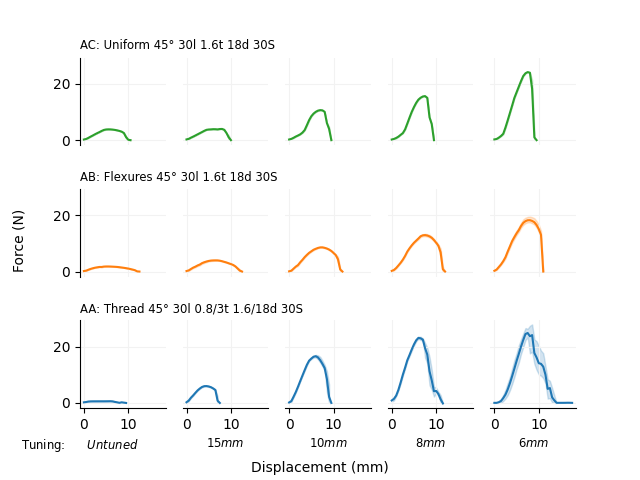

In [1087]:
plt.close('all')
title_params = {
    'Angle': '°',
    'Arm Eff Len': 'l',
    'In-Plane Th': 't',
    'Out-P Th': 'd',
    'Base Width': 'S',
}
mms = (15, 10, 8, 6)

fig, axs = plt.subplots(3,5, sharey=True, sharex=True)
for i,mainmodel in enumerate(('AC', 'AB', 'AA')):
    names = [mainmodel] + [f'{mainmodel}_{mm:02}mm' for mm in mms]
    for model, ax in zip(names, axs[i,:]):
        plots(tune_data, tparams, model_lines, directions=['DOWN'], subset=[model], ax=ax, legend=False)
        ax.grid(color='0.95')
        ax.set_xlabel(None)
        ax.set_ylabel(None)
        ax.label_outer(remove_inner_ticks=True)
        ax.spines.top.set_visible(False)
        ax.spines.right.set_visible(False)
        if ax in axs[:2]:
            ax.spines.bottom.set_visible(False)
        if ax in axs[:,1:]:
            ax.spines.left.set_visible(False)
        else:
            p = tparams.loc[mainmodel].model
            ax.set_title(f'{mainmodel}: ' + 
                p['Arm Type'] + ' ' + ' '.join(
                    [(
                        str(p[param]).replace('.0', '') + title_params[param]
                    ) for param in title_params]
                ),
                fontsize='small', loc='left',
            )
    axs[-1,0].set_xlabel('Tuning:      $\mathit{Untuned}$', x=0, fontsize='small')
    for ax,mm in zip(axs[-1,1:], [f'{mm}mm' for mm in mms]):
        ax.set_xlabel(f'$\mathit{{{mm}}}$', fontsize='small')
fig.supxlabel('Displacement (mm)', fontsize='medium', y=0.01)
fig.supylabel('Force (N)', fontsize='medium')
plt.subplots_adjust(hspace=0.5, bottom=0.15)
fig.canvas.header_visible = False

In [1003]:
plt.subplots_adjust(hspace=.5)

In [1088]:
fig.savefig('/Users/mkn196/Dropbox/Apps/Overleaf/A Tunable Bistable Mechanism/figures/tuning_plots.pdf')

In [911]:
utils.modelinfo2df(Path(utils.MODEL_INFO_PATH))

,Symmetric,Arm Type,Angle,Arm Eff Len,In-Plane Th,Out-P Th,Base Width,w_b_ratio,displacement_calc
Names,,,,,,,,,
AA,True,Thread,45,30,0.8(3),1.6(18),30,1.313333,23.617366
AB,True,Flexures,45,30,1.6,18,30,1.313333,23.617366
AC,True,Uniform,45,30,1.6,18,30,1.313333,23.617366
AD,False,Thread,45,30,0.8(3),1.6(18),30,1.313333,23.617366
AE,False,Flexures,45,30,1.6,18,30,1.313333,23.617366
AF,False,Uniform,45,30,1.6,18,30,1.313333,23.617366
AN,True,Thread,35,30,0.8(3),1.6(18),30,1.313333,19.157453
AO,True,Thread,40,30,0.8(3),1.6(18),30,1.313333,21.469106
AQ,True,Flexures,35,30,1.6,18,30,1.313333,19.157453


In [126]:
data['AD'].loc[(data['AD'].direction == "UP") & (data['AD'].testno == 3)]

,timestamp,direction,force,test_type,z,displacement,testno
115,1.725524e+09,UP,-0.006,careful,-14.84375,9.5,3
116,1.725524e+09,UP,-0.005,careful,-14.34375,9.0,3
117,1.725524e+09,UP,-0.024,careful,-13.84375,8.5,3
118,1.725524e+09,UP,-0.040,careful,-13.34375,8.0,3
119,1.725524e+09,UP,-0.052,careful,-12.84375,7.5,3
120,1.725524e+09,UP,-0.065,careful,-12.34375,7.0,3
121,1.725524e+09,UP,-0.074,careful,-11.84375,6.5,3
122,1.725524e+09,UP,-0.079,careful,-11.34375,6.0,3
123,1.725524e+09,UP,-0.081,careful,-10.84375,5.5,3
124,1.725524e+09,UP,-0.081,careful,-10.34375,5.0,3


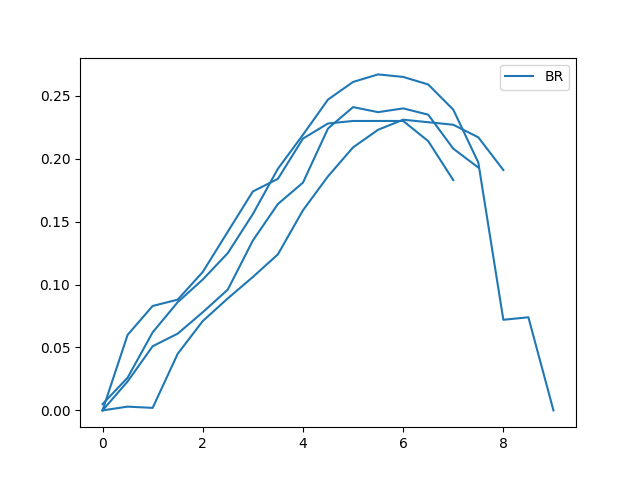

In [122]:
plots(data, params, model_lines, subset=['BR'], directions=['DOWN'], ptype='mpl');

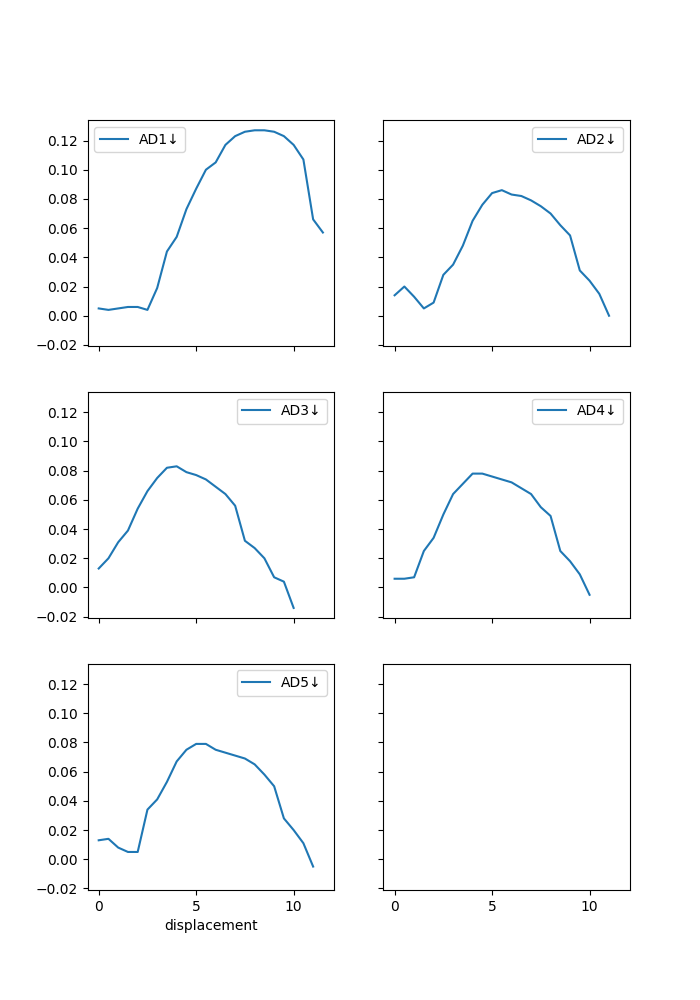

In [125]:
plot_tests(data['AD'])

In [964]:
# Set up consistent line styles for plotting for each model
linestyles = "solid", "dotted", "dashed", "dashdot", (5, (10, 3))
combos = []
for linestyle in linestyles:
    for color in sns.color_palette().as_hex():
        combos.append(dict(linestyle=linestyle, color=color))
if len(params) > len(combos):
    print(f"Warning! More params ({len(params)}) than combos ({len(combos)})!")
        
model_lines = dict(zip(params.index.sort_values(), combos))

In [770]:
params.model['Arm Type'].value_counts()

Arm Type
Uniform     14
Flexures    14
Thread      13
Name: count, dtype: int64

Text(0.5, 1.0, '$34+5=\\bf{good times}$ ok!')

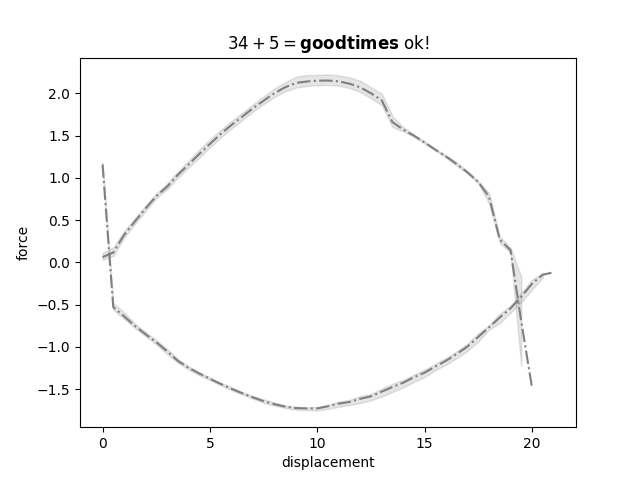

In [883]:
f,ax = plt.subplots()
plots(data, params, model_lines, subset=['BW'], ax=ax, legend=False);
ax.set_title(r'$34+5=\bf{good times}$ ok!')

In [882]:
_?

Type:           Text
String form:    Text(0.5, 1.0, '$34+5=\\bf{good times}\\ ok!$')
File:           ~/.local/pipx/venvs/jupyterlab/lib/python3.11/site-packages/matplotlib/text.py
Docstring:      Handle storing and drawing of text in window or data coordinates.
Init docstring:
Create a `.Text` instance at *x*, *y* with string *text*.

The text is aligned relative to the anchor point (*x*, *y*) according
to ``horizontalalignment`` (default: 'left') and ``verticalalignment``
(default: 'baseline'). See also
:doc:`/gallery/text_labels_and_annotations/text_alignment`.

While Text accepts the 'label' keyword argument, by default it is not
added to the handles of a legend.

Valid keyword arguments are:

Properties:
    agg_filter: a filter function, which takes a (m, n, 3) float array and a dpi value, and returns a (m, n, 3) array and two offsets from the bottom left corner of the image
    alpha: scalar or None
    animated: bool
    antialiased: bool
    backgroundcolor: color
    bbox: dic

In [826]:
ax.set_title(f'{p.Angle}° ${p["Arm Eff Len"]}l$ ${p["In-Plane Th"]}t$ ${p["Out-P Th"]}$', fontsize='small', loc='left')

NameError: name 'p' is not defined

In [1023]:
params

test                                               \
   feedrate test_type test_direction test_loops test_num   
BW      300   careful           DOWN          5        1   
AD      300   careful           DOWN          5        1   
AQ      300   careful           DOWN          5        1   
AE      300   careful           DOWN          5        1   
BC      300   careful           DOWN          5        1   
BV      300   careful           DOWN          5        1   
AB      300   careful           DOWN          5        1   
BH      300   careful           DOWN          5        1   
AW      300   careful           DOWN          5        1   
AN      300   careful           DOWN          5        1   
BQ      300   careful           DOWN          5        1   
BD      300   careful           DOWN          5        1   
BE      300   careful           DOWN          5        1   
BP      300   careful           DOWN          5        1   
AO      300   careful           DOWN          5        1   
AC      300   careful           DOWN          0        1   
AU      300   careful           DOWN          5        1   
BJ      300   careful           DOWN          5        1   
AY      300   careful           DOWN          5        1   
BF      300   careful           DOWN          5        1   
BS      300   careful           DOWN          5        1   
BR      300   careful           DOWN          5        1   
BG      300   careful           DOWN          0        1   
AA      300   careful           DOWN          5        1   
BK      300   careful           DOWN          5        1   
AT      300   careful           DOWN          5        1   
BU      300   careful           DOWN          5        1   
BL      300   careful           DOWN          5        1   
AF      300   careful           DOWN          5        1   
BM      300   careful           DOWN          5        1   
AR      300   careful           DOWN          5        1   
BT      300   careful           DOWN          5        1   
BA      300   careful           DOWN          5        1   

                                                                  model  \
   return_to_zero_after_test n_samples careful_inc stop_after Symmetric   
BW                      True         1         0.5         40      True   
AD                      True         1         0.5         12     False   
AQ                      True         1         0.5         15      True   
AE                      True         1         0.5         15     False   
BC                      True         1         0.5         16      True   
BV                      True         1         0.5         14      True   
AB                      True         1         0.5         15      True   
BH                      True         1         0.5         12      True   
AW                      True         1         0.5         12      True   
AN                      True         1         0.5         10      True   
BQ                      True         1         0.5         16      True   
BD                      True         1         0.5         20      True   
BE                      True         1         0.5         20      True   
BP                      True         1         0.5         16      True   
AO                      True         1         0.5         10      True   
AC                      True         1         0.5         20      True   
AU                      True         1         0.5         15      True   
BJ                      True         1         0.5         18      True   
AY                      True         1         0.5         11      True   
BF                      True         1         0.5         20      True   
BS                      True         1         0.5         30      True   
BR                      True         1         0.5         11      True   
BG                      True         1         0.5         16      True   
AA                      True   

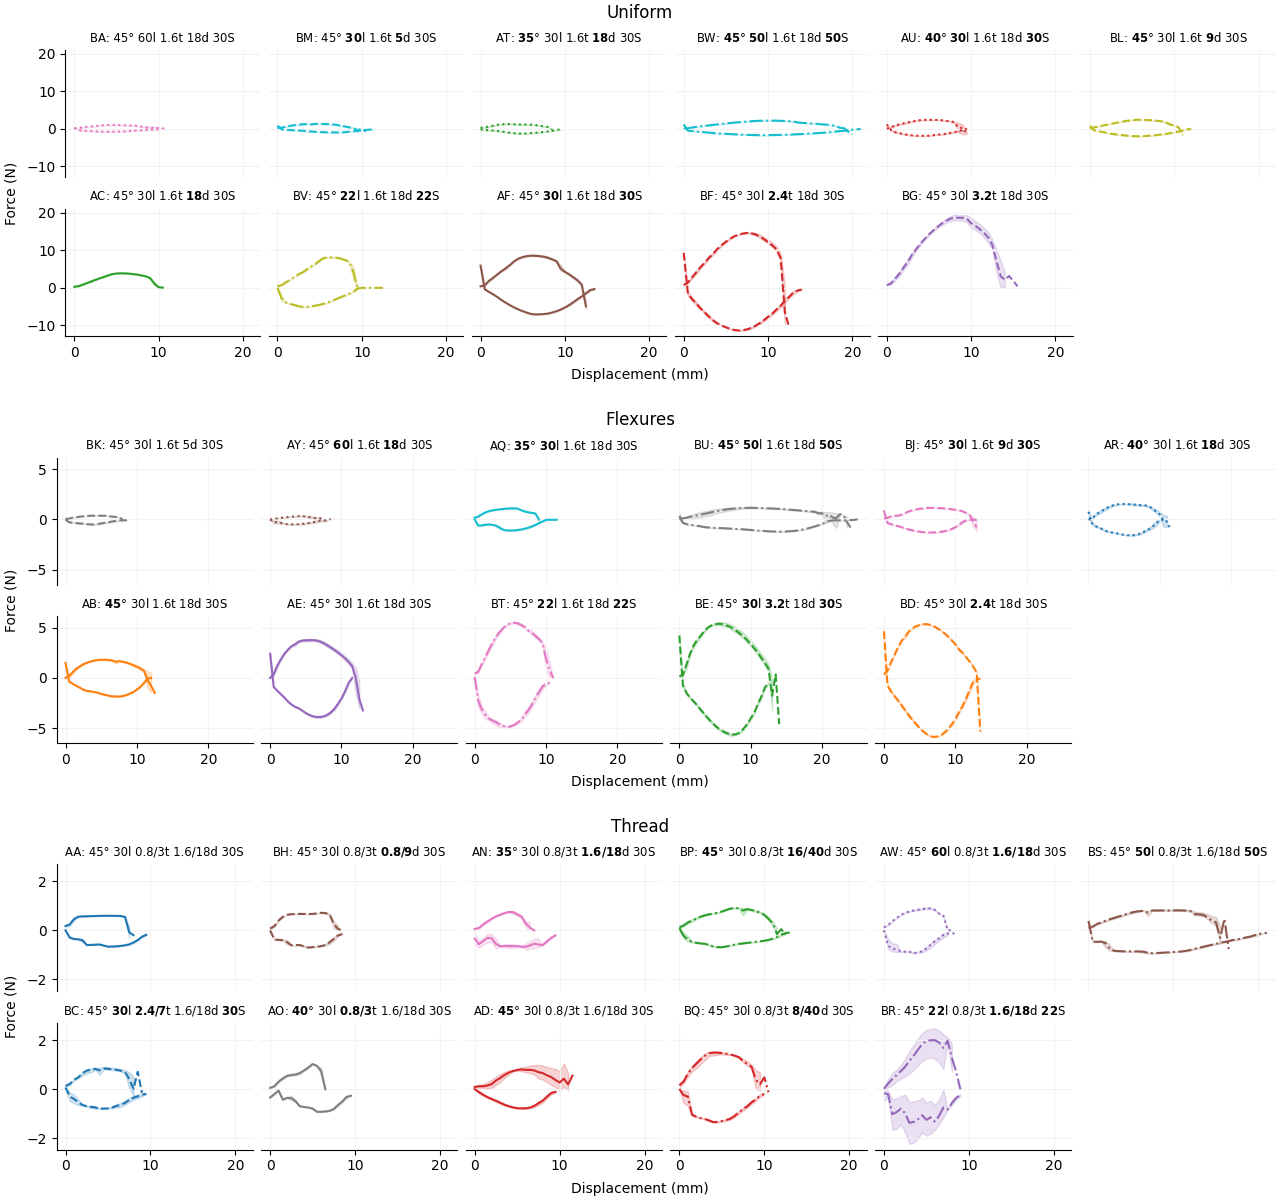

In [1035]:
plt.close('all')
fig = plt.figure(layout='constrained', figsize=(6.4*2,4.8*2.5))
subfigs = fig.subfigures(3,1,hspace=.05)
title_params = {
    'Angle': '°',
    'Arm Eff Len': 'l',
    'In-Plane Th': 't',
    'Out-P Th': 'd',
    'Base Width': 'S',
}

for armtype, sfig in zip(('Uniform', 'Flexures', 'Thread'), subfigs.flat):
    axs = sfig.subplots(2,6,sharex=True,sharey=True)
    names =  sorted([name for name in data if params.loc[name].model['Arm Type']==armtype and name != 'AC-loose'],
                    key=lambda n: data[n].force.abs().max())
    last_params = None
    
    for ax,name in zip(axs.flat, names):
        plots(data, params, model_lines, subset=[name], ax=ax, legend=False)#, directions=['DOWN'])

        p = params.loc[name].model
        
        #Bold part of title if it's different from the last one
        titleparts = [f'{name}:']
        for param in title_params:
            val = str(p[param]).replace('.0', '')
            if last_params is not None and (p[param] != last_params[param]):
                titleparts.append(r'$\bf{' + val + '}$' + title_params[param])
            else:
                titleparts.append(val + title_params[param])
            
        ax.set_title(' '.join(titleparts), fontsize='small')
        
        ax.set_xlabel(None)
        ax.set_ylabel(None)
        ax.grid(color='0.95')
        ax.label_outer(remove_inner_ticks=True)
        ax.spines.top.set_visible(False)
        ax.spines.right.set_visible(False)
        if ax in axs[0]:
            ax.spines.bottom.set_visible(False)
        if ax in axs[:,1:]:
            ax.spines.left.set_visible(False)
        
        sfig.suptitle(armtype)
        sfig.supxlabel('Displacement (mm)', fontsize='medium')
        sfig.supylabel('Force (N)', fontsize='medium')

        last_params = p
    
    for ax in axs.flat:
        if not ax.has_data():
            sfig.delaxes(ax)
        #else:
        ##    ax.set_ylim(-0.5, ax.get_ylim()[1])
        
fig.canvas.header_visible = False

#fig.savefig('/Users/mkn196/Dropbox/Apps/Overleaf/A Tunable Bistable Mechanism/figures/fd_plots.pdf')

In [1036]:
fig.savefig('/Users/mkn196/Dropbox/Apps/Overleaf/A Tunable Bistable Mechanism/figures/fd_plots.pdf')

In [1030]:
ax.set_ylim(-0.5, ax.get_ylim()[1])

(-0.5, 2.624847939)

In [895]:
{armtype: ', '.join(sorted([name for name in data if params.loc[name].model['Arm Type']==armtype and name != 'AC-loose'],
                    key=lambda n: data[n].force.abs().max())) for armtype in ('Uniform', 'Flexures', 'Thread')}

{'Uniform': 'AS, BO, BA, BM, AT, BW, AU, BL, BBV, AC-tight, BV, AF, BF',
 'Flexures': 'BN, BJ, AY, AP, AQ, BU, BK, AR, AB, BBT, AE, BT, BE, BD',
 'Thread': 'AA, BH, AN, AW, BS, BC, AO, BX, BY, AD, BZ, BBR'}

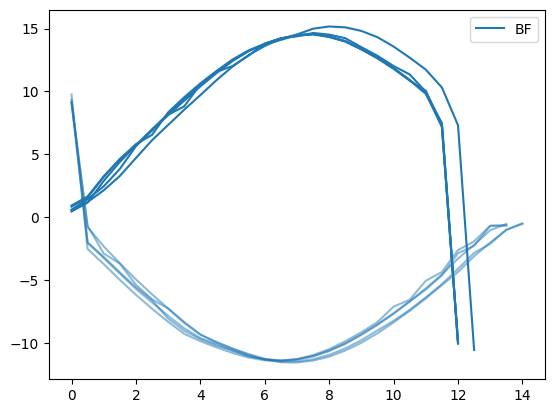

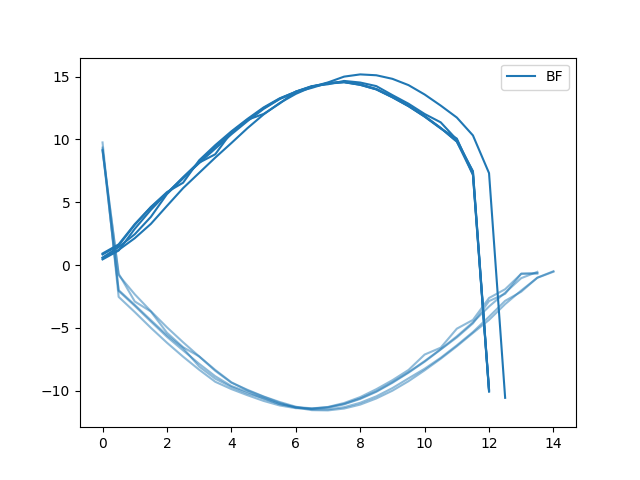

In [898]:
plots(data, params, model_lines, ptype='mpl', subset=['BF'])

In [828]:
params.model.head()

,Symmetric,No Arms,Arm Type,Angle,Arm Eff Len,In-Plane Th,Out-P Th,Base Width,w_b_ratio,displacement_calc
BW,True,2,Uniform,45,50,1.6,18.0,50,0.788,23.617366
AD,False,2,Thread,45,30,1.6,18.0,30,1.313333,23.617366
BN,True,2,Flexures,45,30,1.6,1.6,30,1.313333,23.617366
AQ,True,2,Flexures,35,30,1.6,18.0,30,1.313333,19.157453
AP,True,2,Flexures,30,30,1.6,18.0,30,1.313333,16.7


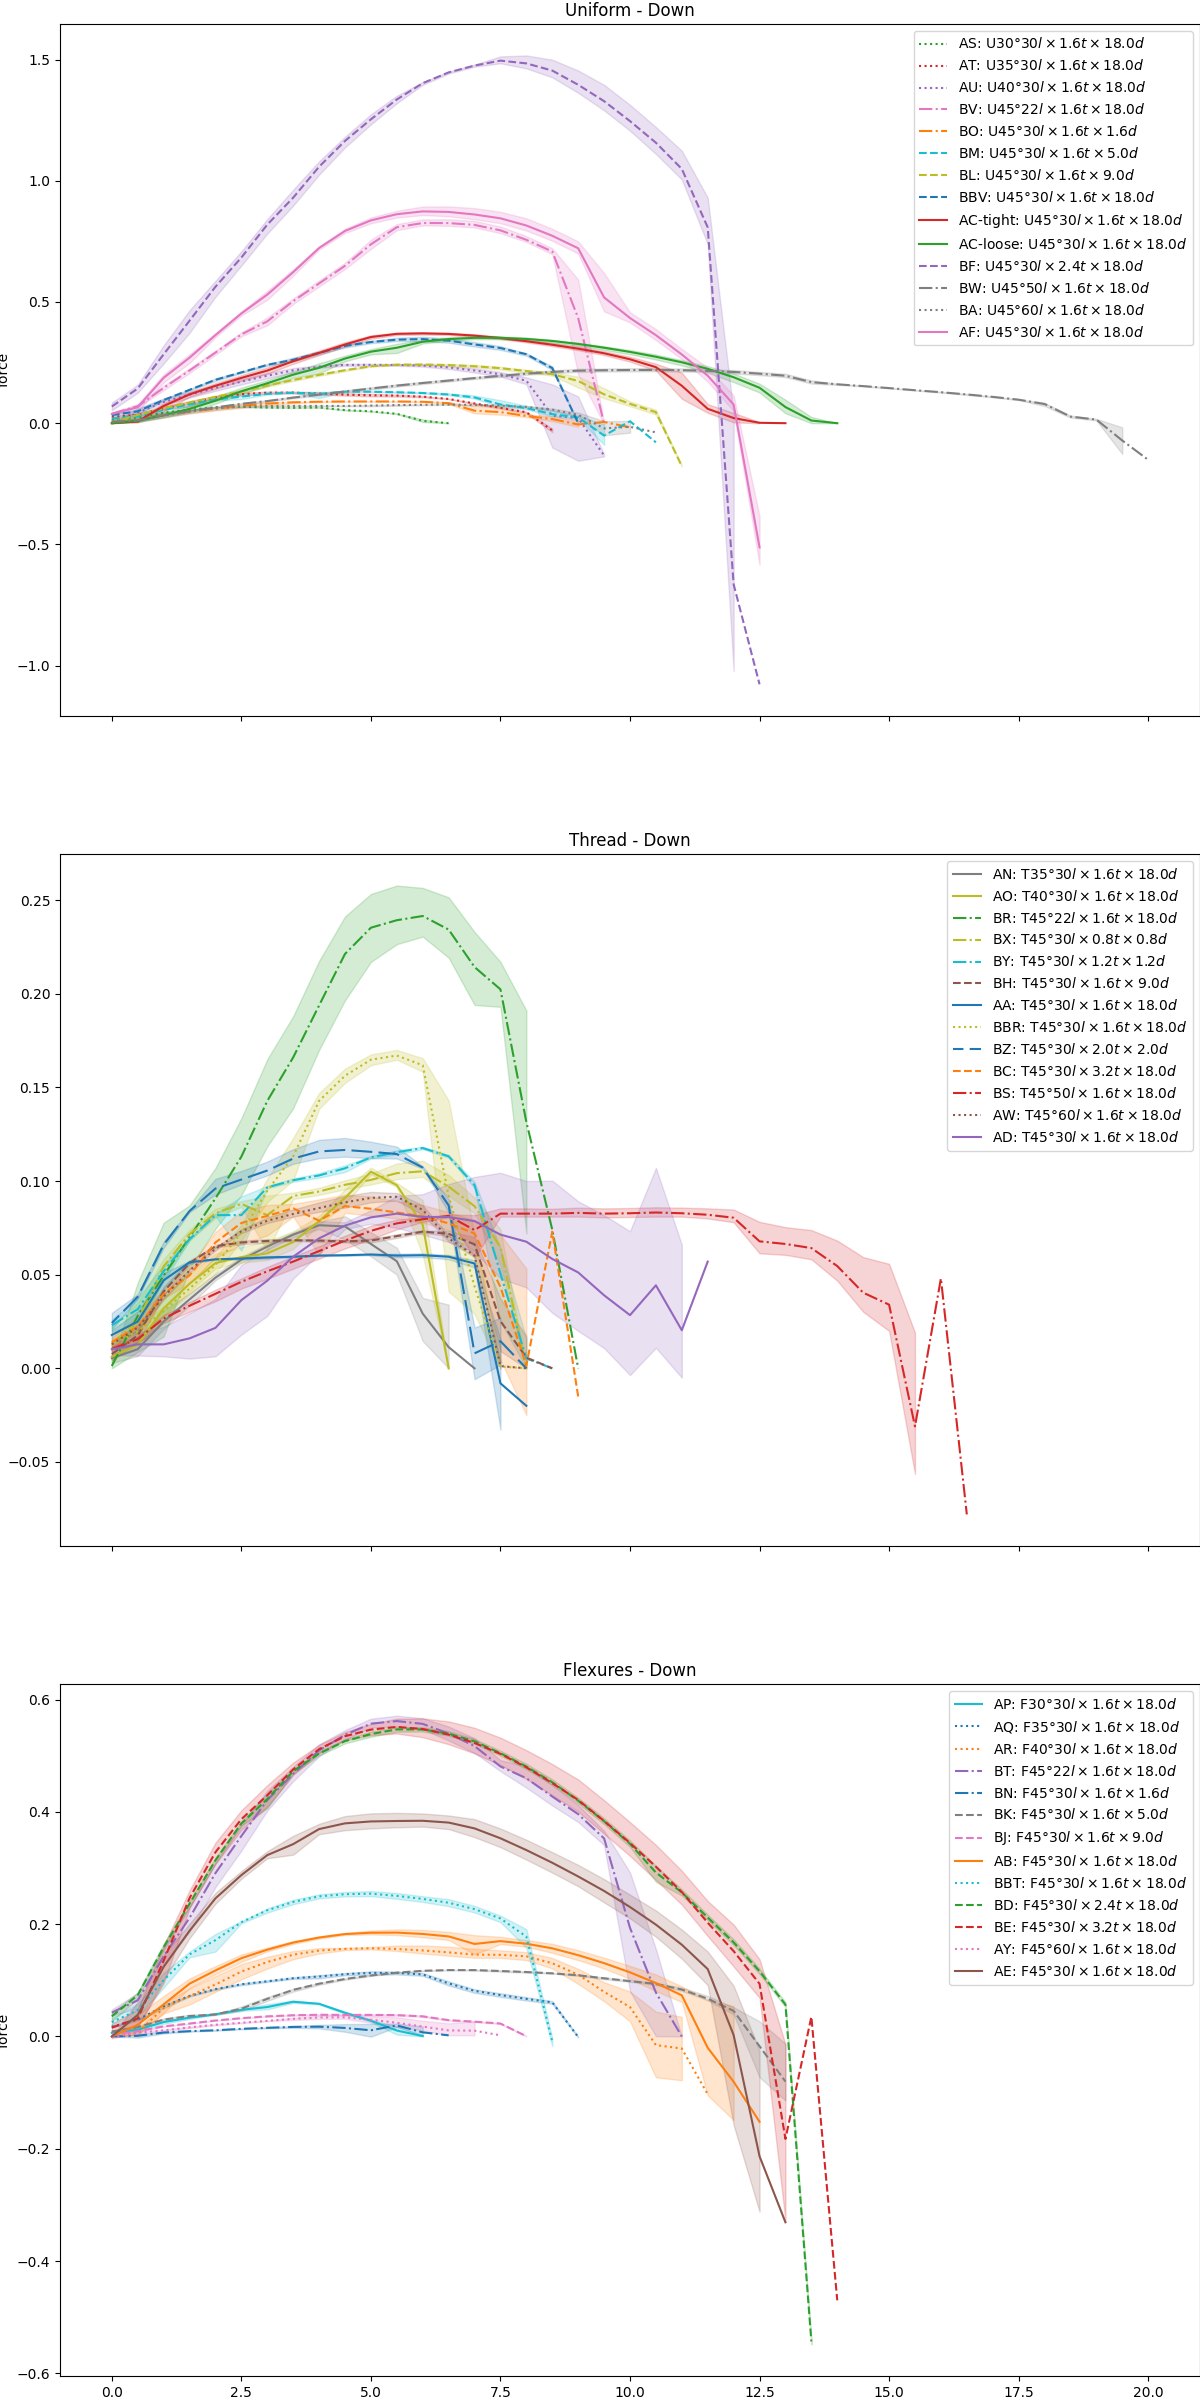

In [124]:
plt.close('all')
fig, axs = plt.subplots(3, figsize=(12,8*3), sharex=True)
for ax,armtype in zip(axs.flat, params.model['Arm Type'].unique()):
    plots(data, params, model_lines, skip=['BU'], directions=['DOWN'], figargs=dict(figsize=(16,8)), inctest=lambda name, df:params.loc[name].model['Arm Type'] == armtype, ax=ax)
    ax.set_title(f"{armtype} - Down")
plt.subplots_adjust(left=0.05,right=1,bottom=0.01,top=.99,wspace=0.1)

In [162]:
fig.savefig('/tmp/by_armtype-down.pdf', bbox_inches='tight')

In [296]:
data['BF'].query('testno == 1')[['direction', 'displacement', 'force']]

,direction,displacement,force
0,DOWN,0.0,0.057
1,DOWN,0.5,0.123
2,DOWN,1.0,0.218
3,DOWN,1.5,0.334
4,DOWN,2.0,0.480
...,...,...,...
61,UP,2.0,0.626
62,UP,1.5,0.505
63,UP,1.0,0.374
64,UP,0.5,0.237


# Statistics

In [1051]:
params.loc['AC']

test   feedrate                           300
       test_type                      careful
       test_direction                    DOWN
       test_loops                           0
       test_num                             1
       return_to_zero_after_test         True
       n_samples                            1
       careful_inc                        0.5
       stop_after                          20
model  Symmetric                         True
       Arm Type                       Uniform
       Angle                               45
       Arm Eff Len                         30
       In-Plane Th                        1.6
       Out-P Th                            18
       Base Width                          30
       w_b_ratio                     1.313333
       displacement_calc            23.617366
Name: AC, dtype: object

In [1037]:
def get_stats(df):
    gb = df.groupby(['direction', 'testno'])

    #Stats grouped by direction then test
    test_stats = pd.concat({
        'max_force': gb.force.apply(lambda x: x.abs().max()),
        'max_displacement': gb.displacement.max(),
    },
    axis=1,
    )
    return test_stats

In [1038]:
def mean_stats(stats):
    tsm = stats.groupby(level='direction').mean()
    tsm.columns = [f'mean_{name}' for name in tsm.columns]
    return tsm

In [1039]:
def statstr(series):
    modelname = series.name
    parts = [modelname]
    parts.extend([f'{col}: {val}' for col,val in params.loc[modelname].model.items()])
    return '\n'.join(parts)
    
def down_plot_anno(df, params):
    fig, ax = plt.subplots()
    labels = []
    for a,sym in zip(df['Arm Type'].unique(), '.*x'):
        df_armtype = df.drop('BU').loc[df['Arm Type'] == a]
        df_armtype.plot(x='mean_max_displacement', y='mean_max_force', style=sym, ax=ax, label=a)
        labels.extend([statstr(model) for idx,model in df_armtype.iterrows()])
    ax.set_ylabel('force')
    mplcursors.cursor(ax,
                      hover=2,
                      annotation_kwargs=dict(
                          bbox=dict(
                              boxstyle="square,pad=0.5",
                              facecolor="white",
                              edgecolor="#ddd",
                              linewidth=0.5,
                          ),
                          linespacing=1.5,
                          arrowprops=None,
                      ),
                      highlight=True,
                      highlight_kwargs=dict(linewidth=2),
                 ).connect('add', lambda sel: sel.annotation.set_text(labels[sel.index]))
    return fig

In [646]:
params.model.loc[['AB', 'AY']]

,Symmetric,No Arms,Arm Type,Angle,Arm Eff Len,In-Plane Th,Out-P Th,Base Width,w_b_ratio,displacement_calc
AB,True,2,Flexures,45,30,1.6,18.0,30,1.313333,23.617366
AY,True,2,Flexures,45,60,1.6,18.0,30,1.313333,23.617366


In [748]:
params.model.sort_index().index.isin(data)

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True])

In [750]:
params.loc['BW'].model

Symmetric                 True
No Arms                      2
Arm Type               Uniform
Angle                       45
Arm Eff Len                 50
In-Plane Th                1.6
Out-P Th                  18.0
Base Width                  50
w_b_ratio                0.788
displacement_calc    23.617366
Name: BW, dtype: object

In [1040]:
stats = get_stats(data['BW']).reset_index()
for col,val in params.loc['BW'].model.items():
    stats[col] = val
stats

,direction,testno,max_force,max_displacement,Symmetric,Arm Type,Angle,Arm Eff Len,In-Plane Th,Out-P Th,Base Width,w_b_ratio,displacement_calc
0,DOWN,1,2.294756,19.5,True,Uniform,45,50,1.6,18,50,0.788,23.617366
1,DOWN,2,2.157463,20.0,True,Uniform,45,50,1.6,18,50,0.788,23.617366
2,DOWN,3,2.118236,19.5,True,Uniform,45,50,1.6,18,50,0.788,23.617366
3,DOWN,4,2.108430,19.5,True,Uniform,45,50,1.6,18,50,0.788,23.617366
4,DOWN,5,2.088816,19.5,True,Uniform,45,50,1.6,18,50,0.788,23.617366
5,UP,1,1.775004,21.0,True,Uniform,45,50,1.6,18,50,0.788,23.617366
6,UP,2,1.735777,20.5,True,Uniform,45,50,1.6,18,50,0.788,23.617366
7,UP,3,1.725970,20.5,True,Uniform,45,50,1.6,18,50,0.788,23.617366
8,UP,4,1.716164,20.5,True,Uniform,45,50,1.6,18,50,0.788,23.617366
9,UP,5,1.716164,20.5,True,Uniform,45,50,1.6,18,50,0.788,23.617366


In [1057]:
def stats_for_prediction(data):
    """Return a DataFrame for use in prediction containing a row for every test."""
    allstats = []
    for name, df in data.items():
        stats = get_stats(df).reset_index()
        for col,val in params.loc[name].model.items():
            if isinstance(val, str) and '/' in val: val = float(val.split('/')[1])
            stats[col] = val
        allstats.append(stats)
    return pd.concat(allstats).reset_index().drop(columns=['index', 'testno'])

allstats = stats_for_prediction(data)

In [1058]:
allstats.head()

,direction,max_force,max_displacement,Symmetric,Arm Type,Angle,Arm Eff Len,In-Plane Th,Out-P Th,Base Width,w_b_ratio,displacement_calc
0,DOWN,2.294756,19.5,True,Uniform,45,50,1.6,18,50,0.788,23.617366
1,DOWN,2.157463,20.0,True,Uniform,45,50,1.6,18,50,0.788,23.617366
2,DOWN,2.118236,19.5,True,Uniform,45,50,1.6,18,50,0.788,23.617366
3,DOWN,2.108430,19.5,True,Uniform,45,50,1.6,18,50,0.788,23.617366
4,DOWN,2.088816,19.5,True,Uniform,45,50,1.6,18,50,0.788,23.617366


In [746]:
allstats.drop(columns=['max_force','max_displacement']).drop_duplicates().query('direction == "DOWN"')

,direction,Symmetric,No Arms,Arm Type,Angle,Arm Eff Len,In-Plane Th,Out-P Th,Base Width,w_b_ratio,displacement_calc
0,DOWN,True,2,Uniform,45,50,1.6,18.0,50,0.788000,23.617366
10,DOWN,False,2,Thread,45,30,1.6,18.0,30,1.313333,23.617366
20,DOWN,True,2,Flexures,45,30,1.6,1.6,30,1.313333,23.617366
30,DOWN,True,2,Flexures,35,30,1.6,18.0,30,1.313333,19.157453
38,DOWN,True,2,Flexures,30,30,1.6,18.0,30,1.313333,16.700000
48,DOWN,True,2,Uniform,45,30,1.6,1.6,30,1.313333,23.617366
58,DOWN,True,2,Thread,45,30,2.0,2.0,30,1.313333,23.617366
68,DOWN,False,2,Flexures,45,30,1.6,18.0,30,1.313333,23.617366
78,DOWN,True,2,Thread,45,30,3.2,18.0,30,1.313333,23.617366
88,DOWN,True,2,Uniform,45,22,1.6,18.0,22,1.790909,23.617366


In [436]:
allstats.displacement_calc.unique()

array([23.61736649, 19.15745297, 16.7       , 21.46910616])

In [1046]:
get_stats(data['AC'])

max_force  max_displacement
direction testno                             
DOWN      0        3.795174              10.5
          1        3.863820              10.5
          2        3.922660              10.5
          3        3.795174              10.5
          4        3.834400              10.0

In [1043]:
down_stats = pd.concat({name: mean_stats(get_stats(data[name])) for name in data}).xs('DOWN', level='direction').sort_values('mean_max_force')
#down_stats = pd.concat([params.model['Arm Type'], down_stats], axis=1)

In [1045]:
down_stats.head()

,mean_max_force,mean_max_displacement
AY,0.339310,6.9
BK,0.378537,8.0
AA,0.600167,7.6
BH,0.717847,8.0
AN,0.766880,6.4


KeyError: 'Arm Type'

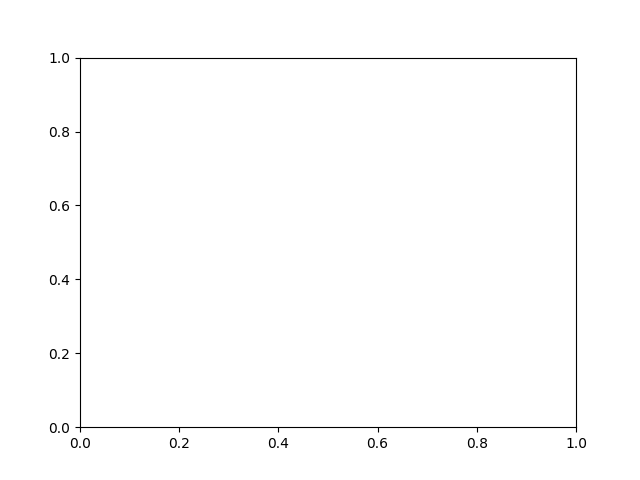

In [1044]:
plt.close()
fig = down_plot_anno(down_stats, params);

In [126]:
plt.close('all')

In [35]:
down_stats['Arm Type'].unique()

array(['Uniform', 'Flexures', 'Thread'], dtype=object)

KeyError: 'Arm Type'

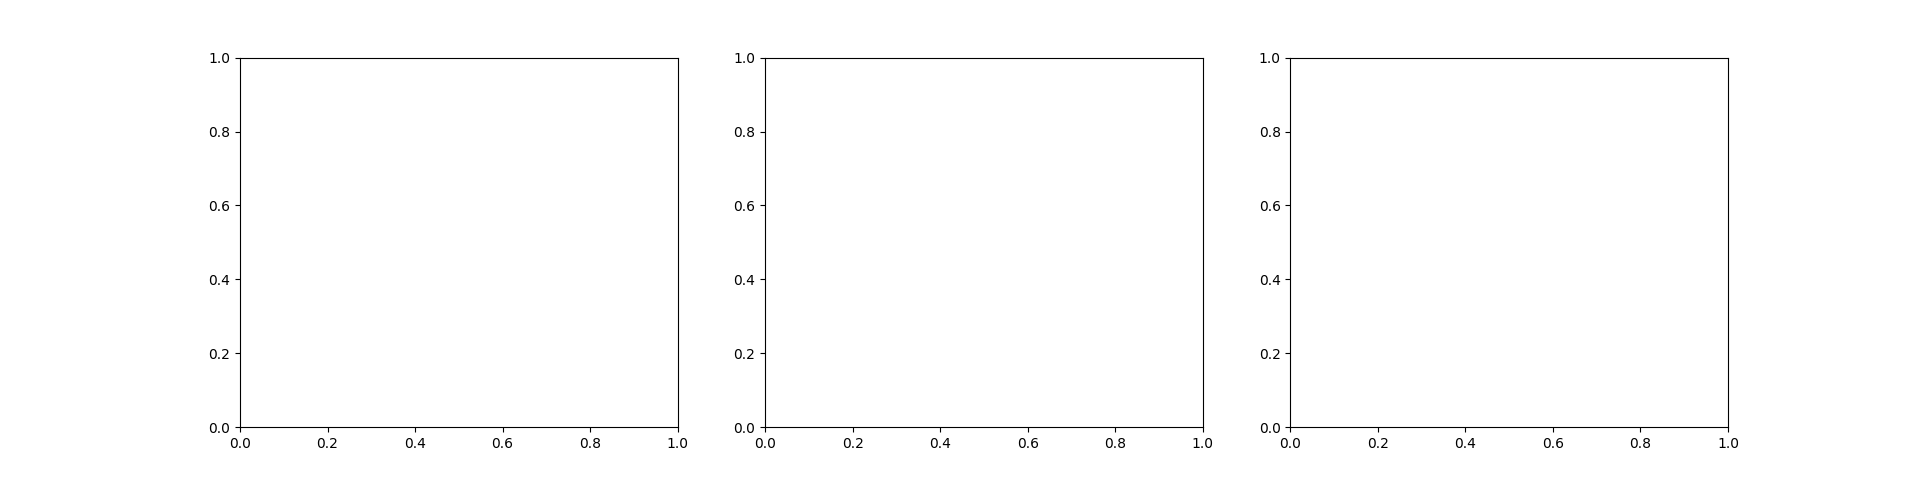

In [1047]:
fig, axs = plt.subplots(1,3, figsize=[6.4*3,4.8])
for a,ax in zip(down_stats['Arm Type'].unique(), axs):
    down_stats.drop('BU').loc[down_stats['Arm Type']==a].plot(x='mean_max_displacement', y='mean_max_force', style='.', ax=ax, label=a)

In [673]:
modeldownstats = pd.concat([down_stats, params['model']], axis=1).sort_index()
modeldownstats.query('Symmetric == False')

,mean_max_force,mean_max_displacement,Symmetric,No Arms,Arm Type,Angle,Arm Eff Len,In-Plane Th,Out-P Th,Base Width,w_b_ratio,displacement_calc
AD,0.0906,10.7,False,2,Thread,45,30,1.6,18.0,30,1.313333,23.617366
AE,0.3852,12.5,False,2,Flexures,45,30,1.6,18.0,30,1.313333,23.617366
AF,0.8746,12.5,False,2,Uniform,45,30,1.6,18.0,30,1.313333,23.617366


In [676]:
modeldownstats.query('(Symmetric == True) & (Angle == 45) & (`In-Plane Th` == 1.6) & (`Out-P Th` == 18.0) & (`Arm Eff Len` == 30) & (`Base Width` == 30)')

,mean_max_force,mean_max_displacement,Symmetric,No Arms,Arm Type,Angle,Arm Eff Len,In-Plane Th,Out-P Th,Base Width,w_b_ratio,displacement_calc
AA,0.0612,7.600000,True,2,Thread,45,30,1.6,18.0,30,1.313333,23.617366
AB,0.1860,11.900000,True,2,Flexures,45,30,1.6,18.0,30,1.313333,23.617366
AC-loose,0.3530,13.666667,True,2,Uniform,45,30,1.6,18.0,30,1.313333,23.617366
AC-tight,0.3708,12.400000,True,2,Uniform,45,30,1.6,18.0,30,1.313333,23.617366


In [ ]:
modeldownstatsF = modeldownstats.copy()
uniques = {}
for col in ['Symmetric', 'Arm Type']:
    modeldownstatsF[col], uniques[col] = modeldownstatsF[col].factorize()
modeldownstatsF.drop(columns=['No Arms'], inplace=True)
modeldownstatsF

In [475]:
allstats.head()

,direction,max_force,max_displacement,Symmetric,No Arms,Arm Type,Angle,Arm Eff Len,In-Plane Th,Out-P Th,Base Width,w_b_ratio,displacement_calc
0,DOWN,0.234,19.5,True,2,Uniform,45,50,1.6,18.0,50,0.788,23.617366
1,DOWN,0.220,20.0,True,2,Uniform,45,50,1.6,18.0,50,0.788,23.617366
2,DOWN,0.216,19.5,True,2,Uniform,45,50,1.6,18.0,50,0.788,23.617366
3,DOWN,0.215,19.5,True,2,Uniform,45,50,1.6,18.0,50,0.788,23.617366
4,DOWN,0.213,19.5,True,2,Uniform,45,50,1.6,18.0,50,0.788,23.617366


<Axes: xlabel='Angle', ylabel='max_displacement'>

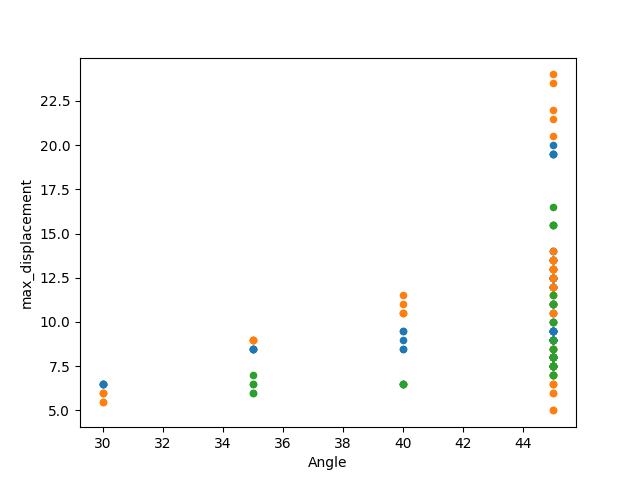

In [686]:
ax = allstats.query('(direction == "DOWN") & (`Arm Type` == "Uniform")').plot('Angle', 'max_displacement', kind='scatter')
allstats.query('(direction == "DOWN") & (`Arm Type` == "Flexures")').plot('Angle', 'max_displacement', kind='scatter', c='tab:orange', ax=ax)
allstats.query('(direction == "DOWN") & (`Arm Type` == "Thread")').plot('Angle', 'max_displacement', kind='scatter', c='tab:green', ax=ax)

In [474]:
corr(allstats[allstats['Arm Type'] == 'Uniform'].drop(columns=['Arm Type', 'Symmetric', 'direction', 'No Arms']))

,max_force,max_displacement,Angle,Arm Eff Len,In-Plane Th,Out-P Th,Base Width,w_b_ratio,displacement_calc
max_force,NaN,0.233096,0.326303,-0.299877,0.777002,0.328276,-0.175232,0.189515,0.324775
max_displacement,0.233096,NaN,0.510369,0.397666,0.151457,0.171569,0.747487,-0.603388,0.509212
Angle,0.326303,0.510369,NaN,0.163561,0.142072,-0.260089,0.023796,0.069260,0.999731
Arm Eff Len,-0.299877,0.397666,0.163561,NaN,-0.095145,0.174179,0.560654,-0.528614,0.161854
In-Plane Th,0.777002,0.151457,0.142072,-0.095145,NaN,0.151296,-0.013843,-0.040289,0.140590
Out-P Th,0.328276,0.171569,-0.260089,0.174179,0.151296,NaN,0.025341,0.073756,-0.257375
Base Width,-0.175232,0.747487,0.023796,0.560654,-0.013843,0.025341,NaN,-0.939875,0.023548
w_b_ratio,0.189515,-0.603388,0.069260,-0.528614,-0.040289,0.073756,-0.939875,NaN,0.068537
displacement_calc,0.324775,0.509212,0.999731,0.161854,0.140590,-0.257375,0.023548,0.068537,NaN


In [1053]:
def corr(data):
    c = data.corr()
    #c[np.tril(c,-1) == 0] = np.nan
    #c.loc['displacement_calc','Angle'] = np.nan
    #c[np.diag(np.ones(len(c))).astype(bool)] = np.nan
    return c
    c[c.eq(1)] = np.nan
    return c.abs()

In [1059]:
corrs = []
for armtype in ('Uniform', 'Flexures', 'Thread', None):
    for direction in (None, 'UP', 'DOWN'):
        queries = []
        if armtype:   queries.append(f"(`Arm Type` == '{armtype}')")
        if direction: queries.append(f"(direction == '{direction}')")
        query = " & ".join(queries)
        corrs.append((
            f'{armtype or "All"}—{direction or "ALL"}',  
            (allstats.query(query) if query else allstats).drop(columns=['Arm Type', 'Symmetric', 'direction']),
            (allstats.query(query) if query else allstats).drop(columns=['Arm Type', 'Symmetric', 'direction']).corr()
        ))

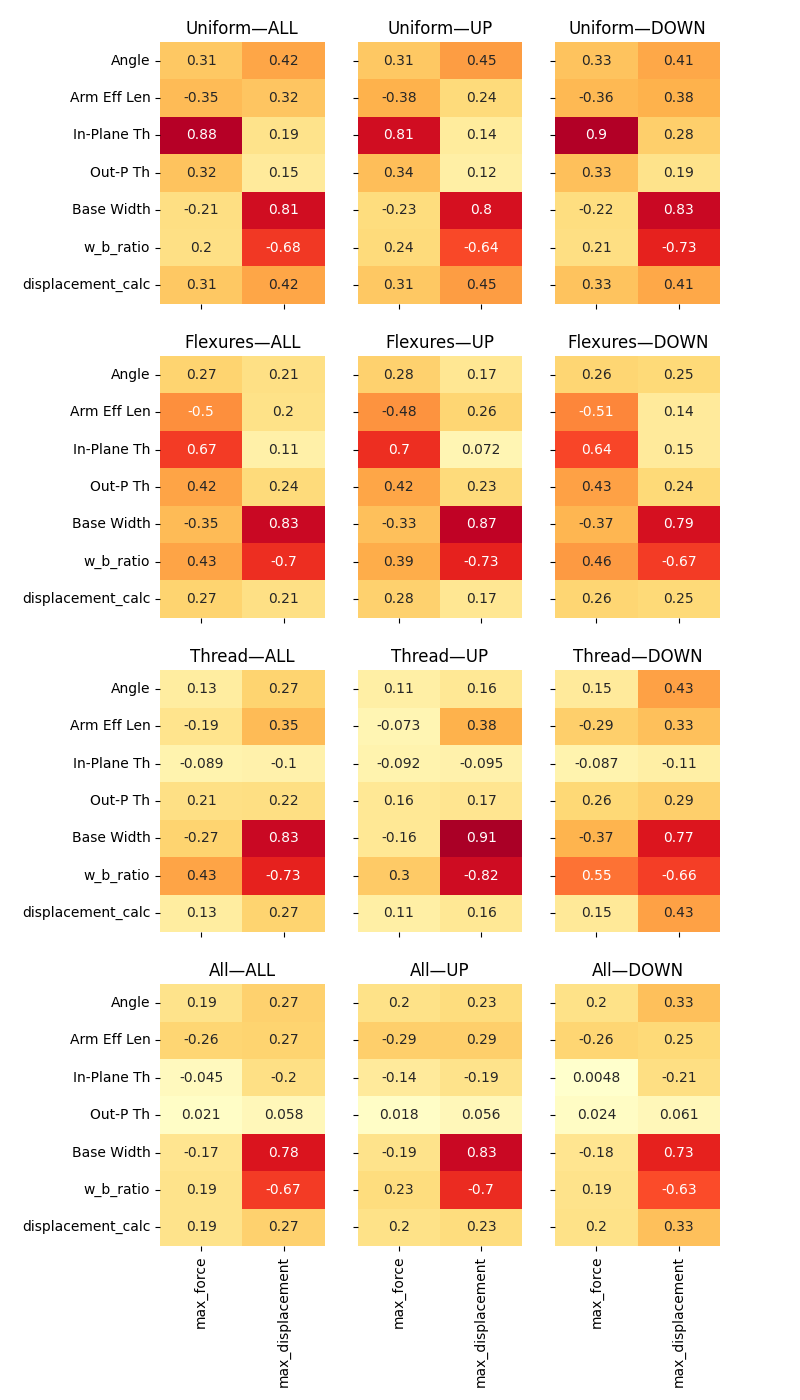

In [1060]:
fig, axs = plt.subplots(4,3, figsize=(8,14), sharey=True, sharex=True)
for ax,(title,cm,c) in zip(axs.flat, corrs):
    sns.heatmap(c[['max_force', 'max_displacement']].iloc[2:], annot=True, cmap=symmetrical_colormap(('YlOrRd', None)), ax=ax, cbar=False, vmin=-1, vmax=1, center=0)
    ax.set_title(title)
plt.subplots_adjust(top=.97, left=.2)#, hspace=.5)
fig.savefig('/tmp/corr.pdf', bbox_inches='tight')

In [470]:
allstats['Arm Type'].value_counts()

Arm Type
Flexures    138
Uniform     131
Thread      129
Name: count, dtype: int64

In [281]:
def linreg(data, armtype, direction='DOWN', predict=['mean_max_force', 'mean_max_displacement']):
    from sklearn.linear_model import LinearRegression
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler

    df = data.loc[(data['Arm Type'] == armtype) & (data.direction == direction)]
    
    X = df.drop(columns=predict + ['Arm Type', 'Symmetric', 'direction', 'No Arms'])
    
    out = {}
    for outcome in predict:
        y = df[outcome]
        X_train, X_test, y_train, y_test = train_test_split(X, y)
    
        model_split = LinearRegression()
        model_split.fit(X_train, y_train)
        model_all = LinearRegression().fit(X, y)
        out[outcome] = X, y, model_all, model_split, X_test, y_test, X_train, y_train
    return out

In [405]:
from sklearn.metrics import mean_squared_error, r2_score

summ = []
perf = []
outcomes = {}
for armtype in allstats['Arm Type'].unique():
    #print(f'{armtype}\n{"="*len(armtype)}')
    o = linreg(allstats, armtype, predict=['max_force', 'max_displacement'])
    outcomes[armtype] = o
    for i, outcome in enumerate(o):
        #print(f'{outcome}\n{"-"*len(outcome)}')
        
        X, y, model_all, model_split, X_test, y_test, X_train, y_train = o[outcome]
        pred_test = model_split.predict(X_test)
        pred_train = model_split.predict(X_train)
        pred_all = model_all.predict(X)

        #print(f'Coeff split:\n{pd.Series(dict(zip(model_split.feature_names_in_, model_split.coef_))).sort_values()}\n')
        #print(f'{outcome}-test MSE, CoD: {mean_squared_error(y_test, pred_test):.2f}, {r2_score(y_test, pred_test):.2f}')
        #print(f'{outcome}-train MSE: {mean_squared_error(y_train, pred_train):2f}')
        #print(f'{outcome}-train CoD: {r2_score(y_train, pred_train):2f}\n')

        coeff = pd.Series(dict(zip(model_all.feature_names_in_, model_all.coef_)), name=f'{armtype}-{outcome}').sort_values()
        summ.append(coeff)
        #print(f'Coeff all:\n{coeff}\n')
        #print(f'{outcome}-all MSE, CoD:  {mean_squared_error(y, pred_all):.2f}, {r2_score(y, pred_all):.2f}\n')
        perf.append(pd.Series(dict(MSE=mean_squared_error(y, pred_all), CoD=r2_score(y, pred_all), name=f'{armtype}-{outcome}')))
        
xx = pd.concat(summ, axis=1)
#print(xx[[c for c in xx.columns if 'force' in c]].T.to_string())
#pd.concat(perf, axis=1).T.set_index('name').MSE
xx.T.loc[xx.T.index.str.contains('force')]

,displacement_calc,Arm Eff Len,Base Width,w_b_ratio,Out-P Th,Angle,In-Plane Th
Uniform-max_force,-0.758017,-0.016593,0.001192,0.002837,0.028835,0.379956,1.212364
Thread-max_force,0.341632,0.000224,0.012594,0.473483,-0.002119,-0.152587,0.008005
Flexures-max_force,-0.330658,-0.010017,0.007714,0.262127,0.018302,0.168354,0.184429


In [417]:
X, y, model_all, model_split, X_test, y_test, X_train, y_train = outcomes['Uniform']['max_force']

In [433]:
pd.Series(model_all.predict(X)).value_counts()

0.529109    16
0.219600     5
0.056222     5
0.653671     5
0.520929     5
0.257748     5
1.499000     5
0.110243     5
0.073255     5
0.269598     5
0.154260     5
0.031326     5
Name: count, dtype: int64

In [431]:
X.iloc[0], y.iloc[0]

(Angle                45.000000
 Arm Eff Len          50.000000
 In-Plane Th           1.600000
 Out-P Th             18.000000
 Base Width           50.000000
 w_b_ratio             0.788000
 displacement_calc    23.617366
 Name: 0, dtype: float64,
 0.234)

In [430]:
sum([X.iloc[0][c] * _405.loc['Uniform-max_force', c] for c in _405.columns])

0.8866337898398429

In [165]:
list(zip(o['mean_max_force'].feature_names_in_, o['mean_max_force'].coef_))

[('Symmetric', 0.38670320436504974),
 ('Angle', 0.030515138125765458),
 ('Arm Eff Len', -0.013676559854498348),
 ('In-Plane Th', 9.378348791999613e-18),
 ('Out-P Th', 0.0249496474143552),
 ('Base Width', -0.003738012446405533)]

In [331]:
allstats.head()

,direction,max_force,max_displacement,Symmetric,No Arms,Arm Type,Angle,Arm Eff Len,In-Plane Th,Out-P Th,Base Width
0,DOWN,0.234,19.5,True,2,Uniform,45,50,1.6,18.0,50
1,DOWN,0.220,20.0,True,2,Uniform,45,50,1.6,18.0,50
2,DOWN,0.216,19.5,True,2,Uniform,45,50,1.6,18.0,50
3,DOWN,0.215,19.5,True,2,Uniform,45,50,1.6,18.0,50
4,DOWN,0.213,19.5,True,2,Uniform,45,50,1.6,18.0,50


In [ ]:
#depvar = 'max_displacement'
depvar = 'max_force'

plotcols = 'Angle', 'Arm Eff Len', 'In-Plane Th', 'Out-P Th', 'Base Width'
fig = plt.figure(layout='constrained', figsize=(12,10))
subfigs = fig.subfigures(2,3, wspace=0.07)

for col, sfig in zip(plotcols, subfigs.flat):
    axs = sfig.subplots(3,1,sharex=True)
    for armtype, ax, c in zip(allstats['Arm Type'].unique(), axs, ('blue', 'orange', 'green')):
        allstats.loc[(allstats.direction == 'DOWN') & (allstats['Arm Type'] == armtype)].plot(col, depvar, ax=ax, kind='scatter', s=12, label=armtype, color=f'tab:{c}', legend=sfig==subfigs.flat[0])
        ylim = ax.get_ylim()

axs = subfigs.flat[-1].subplots(3,1,sharex=True)
for armtype, ax, c in zip(allstats['Arm Type'].unique(), axs.flat, ('blue', 'orange', 'green')):
    ax.scatter(df.Symmetric.astype(int), df[depvar], color=f'tab:{c}', label=armtype, s=12)
    ax.set_xlim(-.5,1.5)
    if 'force' in depvar:
        ax.set_ylim(0,1.5)
    ax.set_xticks([0,1], ['Asymmetric', 'Symmetric'])

fig.savefig(f'/tmp/scatterplots-{depvar}.pdf', bbox_inches='tight')

In [ ]:
modeldownstats.loc[modeldownstats.armtype == 'Uniform', modeldownstats.nunique() > 1].sort_values('mean_max_force')

The only difference for **Uniform** arm types so far is the **angle**, which translates to the maximum width of the system at the snap-through point. It might be more effective to consider that number instead of angle. Maybe the ratio between that length and the arm separation?

<Axes: xlabel='angle', ylabel='mean_max_force'>

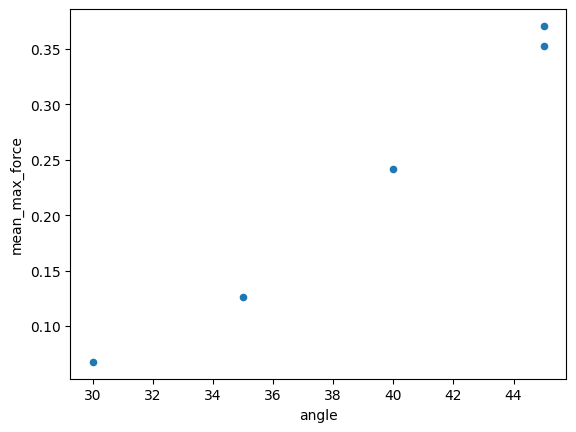

In [533]:
modeldownstats.loc[modeldownstats.armtype=='Uniform'].plot.scatter('angle', 'mean_max_force')

In [538]:
modeldownstats.loc[(modeldownstats.armtype == 'Flexures'), modeldownstats.nunique() > 1].sort_values('mean_max_force')

,mean_max_force,mean_max_displacement,symmetric,armtype,angle,armthick,armdepth
BN,0.0194,5.7,symmetric,Flexures,45,1.6,1.6
BJ,0.0386,7.6,symmetric,Flexures,45,1.6,9.0
AP,0.0618,5.4,symmetric,Flexures,30,1.6,18.0
AQ,0.0938,7.0,symmetric,Flexures,35,1.6,18.0
BK,0.1184,12.3,symmetric,Flexures,45,1.6,5.0
AR-01,0.1596,10.3,symmetric,Flexures,40,1.6,18.0
AR,0.1724,10.2,symmetric,Flexures,40,1.6,18.0
AB,0.1860,11.4,symmetric,Flexures,45,1.6,18.0
AE,0.3852,12.0,asymmetric,Flexures,45,1.6,18.0
BD,0.5472,13.0,symmetric,Flexures,45,2.4,18.0


<Axes: xlabel='angle', ylabel='mean_max_force'>

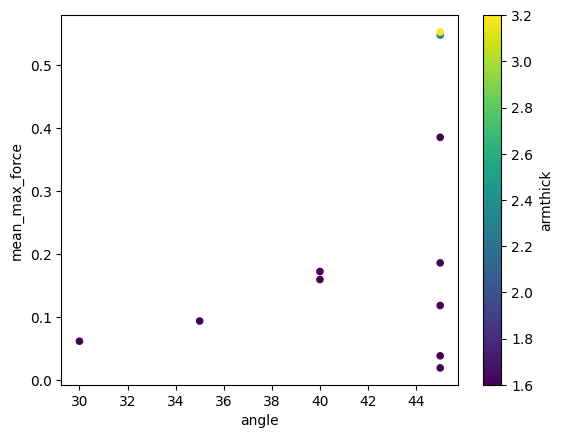

In [540]:
_538.plot.scatter('angle', 'mean_max_force', c='armthick')

In [ ]:
plots(data, subset=['AP', 'AC-tight'], directions=['DOWN'])

<Axes: xlabel='angle', ylabel='mean_max_force'>

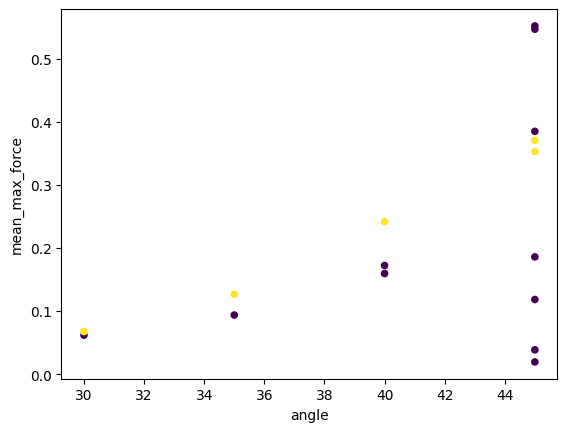

In [510]:
modeldownstats.plot.scatter('angle', 'mean_max_force', c=[0 if v == 'Flexures' else 1 for v in modeldownstats.armtype])

,mean_max_force,mean_max_displacement,"(test, feedrate)","(test, test_type)","(test, test_direction)","(test, test_loops)","(test, test_num)","(test, return_to_zero_after_test)","(test, n_samples)","(test, careful_inc)","(test, stop_after)","(model, symmetric)","(model, no_arms)","(model, armtype)","(model, angle)","(model, armlen)","(model, armthick)","(model, armdepth)","(model, armsep)"
BN,0.0194,5.7,300,careful,DOWN,5,1,True,1,0.5,15,symmetric,2,Flexures,45,30,1.6,1.6,30
BJ,0.0386,7.6,300,careful,DOWN,5,1,True,1,0.5,10,symmetric,2,Flexures,45,30,1.6,9.0,30
AP,0.0618,5.4,300,careful,DOWN,5,1,True,1,0.5,10,symmetric,2,Flexures,30,30,1.6,18.0,30
AS,0.0676,6.0,300,careful,DOWN,5,1,True,1,0.5,15,symmetric,2,Uniform,30,30,1.6,18.0,30
AQ,0.0938,7.0,300,careful,DOWN,5,1,True,1,0.5,15,symmetric,2,Flexures,35,30,1.6,18.0,30
BK,0.1184,12.3,300,careful,DOWN,5,1,True,1,0.5,18,symmetric,2,Flexures,45,30,1.6,5.0,30
AT,0.1266,8.0,300,careful,DOWN,5,1,True,1,0.5,10,symmetric,2,Uniform,35,30,1.6,18.0,30
AR-01,0.1596,10.3,300,careful,DOWN,5,1,True,1,0.5,15,symmetric,2,Flexures,40,30,1.6,18.0,30
AR,0.1724,10.2,300,careful,DOWN,5,1,True,1,0.5,15,symmetric,2,Flexures,40,30,1.6,18.0,30
AB,0.186,11.4,300,careful,DOWN,5,1,True,1,0.5,15,symmetric,2,Flexures,45,30,1.6,18.0,30


In [541]:
modelinfo = pd.read_csv('results/models.csv')

In [545]:
modelinfo.sort_values(['armtype', 'symmetric', 'no_arms', 'armthick', 'angle', 'armdepth'], ascending=[False, False, True, True, True, True])

,name,symmetric,no_arms,armtype,angle,armlen,armthick,armdepth,armsep
47,BZZ,symmetric,2,Uniform,45,15,0.8,2.2,15
18,AS,symmetric,2,Uniform,30,30,1.6,18.0,30
19,AT,symmetric,2,Uniform,35,30,1.6,18.0,30
20,AU,symmetric,2,Uniform,40,30,1.6,18.0,30
40,BO,symmetric,2,Uniform,45,30,1.6,1.6,30
38,BM,symmetric,2,Uniform,45,30,1.6,5.0,30
37,BL,symmetric,2,Uniform,45,30,1.6,9.0,30
2,AC,symmetric,2,Uniform,45,30,1.6,18.0,30
25,AZ,symmetric,2,Uniform,45,15,1.6,18.0,30
26,BA,symmetric,2,Uniform,45,60,1.6,18.0,30


In [556]:
[modelinfo.loc[modelinfo.armtype == 'Uniform', col].value_counts() for col in modelinfo.columns[1:]]

[symmetric
 symmetric     14
 asymmetric     1
 Name: count, dtype: int64,
 no_arms
 2    13
 3     1
 4     1
 Name: count, dtype: int64,
 armtype
 Uniform    15
 Name: count, dtype: int64,
 angle
 45    12
 30     1
 35     1
 40     1
 Name: count, dtype: int64,
 armlen
 30    12
 15     2
 60     1
 Name: count, dtype: int64,
 armthick
 1.6    12
 2.4     1
 3.2     1
 0.8     1
 Name: count, dtype: int64,
 armdepth
 18.0    11
 9.0      1
 5.0      1
 1.6      1
 2.2      1
 Name: count, dtype: int64,
 armsep
 30    14
 15     1
 Name: count, dtype: int64]

In [562]:
angs = modelinfo.query('(armdepth == 18) & (armthick == 1.6) & (symmetric == "symmetric") & (no_arms == 2) & (armlen == 30)')
angs.loc[:,angs.nunique() > 1].sort_values(['armtype', 'angle'])

,name,armtype,angle
15,AP,Flexures,30
16,AQ,Flexures,35
17,AR,Flexures,40
1,AB,Flexures,45
12,AM,Thread,30
13,AN,Thread,35
14,AO,Thread,40
0,AA,Thread,45
18,AS,Uniform,30
19,AT,Uniform,35


## Model variations

### Angle variation
These are the models where the angle varies from 45°; the _only_ variation is the angle and the arm type.

In [575]:
var_angle = modelinfo.query('(angle != 45)')
var_angle

,name,symmetric,no_arms,armtype,angle,armlen,armthick,armdepth,armsep
12,AM,symmetric,2,Thread,30,30,1.6,18.0,30
13,AN,symmetric,2,Thread,35,30,1.6,18.0,30
14,AO,symmetric,2,Thread,40,30,1.6,18.0,30
15,AP,symmetric,2,Flexures,30,30,1.6,18.0,30
16,AQ,symmetric,2,Flexures,35,30,1.6,18.0,30
17,AR,symmetric,2,Flexures,40,30,1.6,18.0,30
18,AS,symmetric,2,Uniform,30,30,1.6,18.0,30
19,AT,symmetric,2,Uniform,35,30,1.6,18.0,30
20,AU,symmetric,2,Uniform,40,30,1.6,18.0,30


### Symmetry variation

In [576]:
var_symmetric = modelinfo.query('symmetric == "asymmetric"')
var_symmetric

,name,symmetric,no_arms,armtype,angle,armlen,armthick,armdepth,armsep
3,AD,asymmetric,2,Thread,45,30,1.6,18.0,30
4,AE,asymmetric,2,Flexures,45,30,1.6,18.0,30
5,AF,asymmetric,2,Uniform,45,30,1.6,18.0,30


### Arm number variation

In [577]:
var_no_arms = modelinfo.query('no_arms != 2')
var_no_arms

,name,symmetric,no_arms,armtype,angle,armlen,armthick,armdepth,armsep
6,AG,symmetric,3,Thread,45,30,1.6,18.0,30
7,AH,symmetric,3,Flexures,45,30,1.6,18.0,30
8,AI,symmetric,3,Uniform,45,30,1.6,18.0,30
9,AJ,symmetric,4,Thread,45,30,1.6,18.0,30
10,AK,symmetric,4,Flexures,45,30,1.6,18.0,30
11,AL,symmetric,4,Uniform,45,30,1.6,18.0,30


### Arm thickness variation
Note here there are also some variations in `armdepth` and `armsep`, so I'm pulling those out separately.

In [584]:
var_armthick = modelinfo.query('(armthick != 1.6) & (armdepth == 18)')
var_armthick.sort_values(['armthick'])

,name,symmetric,no_arms,armtype,angle,armlen,armthick,armdepth,armsep
27,BB,symmetric,2,Thread,45,30,2.4,18.0,30
29,BD,symmetric,2,Flexures,45,30,2.4,18.0,30
31,BF,symmetric,2,Uniform,45,30,2.4,18.0,30
28,BC,symmetric,2,Thread,45,30,3.2,18.0,30
30,BE,symmetric,2,Flexures,45,30,3.2,18.0,30
32,BG,symmetric,2,Uniform,45,30,3.2,18.0,30


### Arm separation variation
Note `armdepth` and `armthick` also vary.

In [587]:
var_armsep = modelinfo.query('armsep != 30')
var_armsep

,name,symmetric,no_arms,armtype,angle,armlen,armthick,armdepth,armsep
46,BYY,symmetric,2,Thread,45,15,1.6,1.6,15
47,BZZ,symmetric,2,Uniform,45,15,0.8,2.2,15


In [588]:
pd.concat([modelinfo, var_angle, var_no_arms, var_symmetric, var_armthick, var_armsep]).drop_duplicates(keep=False).sort_values(['armtype'])

,name,symmetric,no_arms,armtype,angle,armlen,armthick,armdepth,armsep
1,AB,symmetric,2,Flexures,45,30,1.6,18.0,30
23,AX,symmetric,2,Flexures,45,15,1.6,18.0,30
24,AY,symmetric,2,Flexures,45,60,1.6,18.0,30
39,BN,symmetric,2,Flexures,45,30,1.6,1.6,30
36,BK,symmetric,2,Flexures,45,30,1.6,5.0,30
35,BJ,symmetric,2,Flexures,45,30,1.6,9.0,30
0,AA,symmetric,2,Thread,45,30,1.6,18.0,30
43,BX,symmetric,2,Thread,45,30,0.8,0.8,30
42,BQ,symmetric,2,Thread,45,30,1.6,8.0,30
41,BP,symmetric,2,Thread,45,30,1.6,16.0,30


In [589]:
groups = modelinfo[modelinfo.drop_duplicates().duplicated(subset=modelinfo.columns.difference(modelinfo.columns[modelinfo.nunique() > 1]), keep=False)]

ValueError: not enough values to unpack (expected 2, got 0)

In [596]:
print(modelinfo)

   name   symmetric  no_arms   armtype  angle  armlen  armthick  armdepth  armsep
0    AA   symmetric        2    Thread     45      30       1.6      18.0      30
1    AB   symmetric        2  Flexures     45      30       1.6      18.0      30
2    AC   symmetric        2   Uniform     45      30       1.6      18.0      30
3    AD  asymmetric        2    Thread     45      30       1.6      18.0      30
4    AE  asymmetric        2  Flexures     45      30       1.6      18.0      30
5    AF  asymmetric        2   Uniform     45      30       1.6      18.0      30
6    AG   symmetric        3    Thread     45      30       1.6      18.0      30
7    AH   symmetric        3  Flexures     45      30       1.6      18.0      30
8    AI   symmetric        3   Uniform     45      30       1.6      18.0      30
9    AJ   symmetric        4    Thread     45      30       1.6      18.0      30
10   AK   symmetric        4  Flexures     45      30       1.6      18.0      30
11   AL   symmet

In [598]:
pd.options.display.width = 80

In [757]:
rparams = params.model.query('Symmetric == True').drop(columns=['Symmetric','No Arms','w_b_ratio','displacement_calc'])
rparams.columns

Index(['Arm Type', 'Angle', 'Arm Eff Len', 'In-Plane Th', 'Out-P Th',
       'Base Width'],
      dtype='object')

In [758]:
rparams.groupby(['Arm Eff Len','In-Plane Th','Out-P Th','Base Width'])['Angle'].nunique()

Arm Eff Len  In-Plane Th  Out-P Th  Base Width
22           1.6          18.0      22            1
30           0.8          0.8       30            1
             1.2          1.2       30            1
             1.6          1.6       30            1
                          5.0       30            1
                          9.0       30            1
                          18.0      22            1
                                    30            4
             2.0          2.0       30            1
             2.4          18.0      30            1
             3.2          18.0      30            1
50           1.6          18.0      50            1
60           1.6          18.0      30            1
Name: Angle, dtype: int64

In [649]:
params.model.columns

Index(['Symmetric', 'No Arms', 'Arm Type', 'Angle', 'Arm Eff Len',
       'In-Plane Th', 'Out-P Th', 'Base Width', 'w_b_ratio',
       'displacement_calc'],
      dtype='object')

In [726]:
len(params)

41

In [ ]:
params.model.to_csv(open('/tmp/params.csv', 'w'))

In [741]:
group_columns = [
#    'Symmetric',
	'Angle',
	'Base Width',
	'In-Plane Th',
	'Out-P Th',
	'Arm Eff Len',
]
groups = params.model.drop(columns=['Symmetric']).groupby(group_columns)['Arm Type'].nunique()
gdf =  groups.sort_values(ascending=False).reset_index()
{col: sorted(gdf[col].unique()) for col in group_columns}

{'Angle': [30, 35, 40, 45],
 'Base Width': [22, 30, 50],
 'In-Plane Th': [0.8, 1.2, 1.6, 2.0, 2.4, 3.2],
 'Out-P Th': [0.8, 1.2, 1.6, 2.0, 5.0, 9.0, 18.0],
 'Arm Eff Len': [22, 30, 50, 60]}

In [731]:
{i[1:] for i in _730.tolist()}

{(22, 1.6, 18.0, 22),
 (22, 1.6, 18.0, 30),
 (30, 0.8, 0.8, 30),
 (30, 1.2, 1.2, 30),
 (30, 1.6, 1.6, 30),
 (30, 1.6, 5.0, 30),
 (30, 1.6, 9.0, 30),
 (30, 1.6, 18.0, 30),
 (30, 1.6, 18.0, 60),
 (30, 2.0, 2.0, 30),
 (30, 2.4, 18.0, 30),
 (30, 3.2, 18.0, 30),
 (50, 1.6, 18.0, 50)}

In [608]:
groups[groups < 3].unstack().fillna(0)

armsep                                             15   30
symmetric no_arms angle armlen armthick armdepth          
symmetric 2       45    15     0.8      2.2       1.0  0.0
                               1.6      1.6       1.0  0.0
                        30     0.8      0.8       0.0  1.0
                               1.6      1.6       0.0  2.0
                                        8.0       0.0  1.0
                                        16.0      0.0  1.0
                               1.2      1.2       0.0  1.0
                               2.0      2.0       0.0  1.0

In [652]:
groups[groups == 3].unstack()

Base Width                                         22   30   50
Symmetric Angle Arm Eff Len In-Plane Th Out-P Th               
False     45    30          1.6         18.0      NaN  3.0  NaN
True      45    22          1.6         18.0      3.0  NaN  NaN
                30          1.6         18.0      3.0  3.0  NaN
                                        9.0       NaN  3.0  NaN
                50          1.6         18.0      NaN  NaN  3.0
                60          1.6         18.0      NaN  3.0  NaN
          35    30          1.6         18.0      NaN  3.0  NaN
          40    30          1.6         18.0      NaN  3.0  NaN

In [611]:
print(_609.to_latex())

\begin{tabular}{llllllr}
\toprule
 &  &  &  &  & armsep & 30 \\
symmetric & no_arms & angle & armlen & armthick & armdepth &  \\
\midrule
asymmetric & 2 & 45 & 30 & 1.600000 & 18.000000 & 3 \\
\cline{1-7} \cline{2-7} \cline{3-7} \cline{4-7} \cline{5-7}
\multirow[t]{12}{*}{symmetric} & \multirow[t]{10}{*}{2} & 30 & 30 & 1.600000 & 18.000000 & 3 \\
\cline{3-7} \cline{4-7} \cline{5-7}
 &  & 35 & 30 & 1.600000 & 18.000000 & 3 \\
\cline{3-7} \cline{4-7} \cline{5-7}
 &  & 40 & 30 & 1.600000 & 18.000000 & 3 \\
\cline{3-7} \cline{4-7} \cline{5-7}
 &  & \multirow[t]{7}{*}{45} & 15 & 1.600000 & 18.000000 & 3 \\
\cline{4-7} \cline{5-7}
 &  &  & \multirow[t]{5}{*}{30} & \multirow[t]{3}{*}{1.600000} & 18.000000 & 3 \\
 &  &  &  &  & 5.000000 & 3 \\
 &  &  &  &  & 9.000000 & 3 \\
\cline{5-7}
 &  &  &  & 2.400000 & 18.000000 & 3 \\
\cline{5-7}
 &  &  &  & 3.200000 & 18.000000 & 3 \\
\cline{4-7} \cline{5-7}
 &  &  & 60 & 1.600000 & 18.000000 & 3 \\
\cline{2-7} \cline{3-7} \cline{4-7} \cline{5-7}
 & 3 